This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

## Additional Variable Information

InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.

StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.

Description: Product (item) name. Nominal.

Quantity: The quantities of each product (item) per transaction. Numeric.

InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.

UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.

Country: Country name. Nominal. The name of the country where a customer resides.

In [ ]:
# extracting the data using zipfile
import zipfile
with zipfile.ZipFile('/content/online+retail+ii.zip','r') as zip_ref:
    zip_ref.extractall()



In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
from  sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




pd.set_option('display.max_columns',999)

In [ ]:
data = pd.read_excel('/content/online_retail_II.xlsx')
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [ ]:
data.describe(include = 'O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [ ]:
# Undestanding the mising values in customer id
data[data['Customer ID'].isnull()]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [ ]:
data[data['Quantity']<0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [ ]:
data['Invoice'].tolist()

[489434,
 489434,
 489434,
 489434,
 489434,
 489434,
 489434,
 489434,
 489435,
 489435,
 489435,
 489435,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489436,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489437,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489438,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489439,
 489440,
 489440,
 489441,
 489441,
 489441,
 489441,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 489442,
 

In [ ]:
# COnverting the column Invoice to string to extract all the cancelled Invoices with 'C'
data['Invoice'] = data['Invoice'].astype('str')
data[data['Invoice'].str.match("^\\d{6}$")==False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [ ]:
# To check for other alphabets
data['Invoice'].str.replace('[0-9]','',regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [ ]:
data[data['Invoice'].str.startswith('A')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [ ]:
# To check if the stock code is a 5 digit number
data['StockCode'] = data['StockCode'].astype(str)

# The stockCode contains numbers along with the letters at the end
data[(data["StockCode"].str.match("^\\{5}$")==False) &  (data['StockCode'].str.match("^\\d{5}[a-zA-Z]+$")==False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
data[(data["StockCode"].str.match("^\\{5}$")==False) &  (data['StockCode'].str.match("^\\{5}[a-zA-Z]+$")==False)]['StockCode'].unique()

array(['85048', '79323P', '79323W', ..., '22935', '22933', '21120'],
      dtype=object)

In [ ]:
data[(data["StockCode"].str.match("^\\d{5}$") == False) & (data["StockCode"].str.match("^\\d{5}[a-zA-Z]+$") == False)]["StockCode"].unique()


array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

In [ ]:
data[data['StockCode'].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
524272,538071,DOT,DOTCOM POSTAGE,1,2010-12-09 14:09:00,885.94,NaN,United Kingdom
524887,538148,DOT,DOTCOM POSTAGE,1,2010-12-09 16:26:00,547.32,NaN,United Kingdom
525000,538149,DOT,DOTCOM POSTAGE,1,2010-12-09 16:27:00,620.68,NaN,United Kingdom
525126,538153,DOT,DOTCOM POSTAGE,1,2010-12-09 16:31:00,822.94,NaN,United Kingdom


StockCode is meant to follow the pattern [0-9]{5} but seems to have legit values for [0-9]{5}[a-zA-Z]+
Also contains other values:
StockCode is meant to follow the pattern [0-9]{5} but seems to have legit values for [0-9]{5}[a-zA-Z]+
Also contains other values: | Code | Description | Action | |---------------------|------------------------------------------------------------------------|-------------------------| | DCGS | Looks valid, some quantities are negative though and customer ID is null | Exclude from clustering | | D | Looks valid, represents discount values | Exclude from clustering | | DOT | Looks valid, represents postage charges | Exclude from clustering | | M or m | Looks valid, represents manual transactions | Exclude from clustering | | C2 | Carriage transaction - not sure what this means | Exclude from clustering | | C3 | Not sure, only 1 transaction | Exclude | | BANK CHARGES or B | Bank charges | Exclude from clustering | | S | Samples sent to customer | Exclude from clustering | | TESTXXX | Testing data, not valid | Exclude from clustering | | gift__XXX | Purchases with gift cards, might be interesting for another analysis, but no customer data | Exclude | | PADS | Looks like a legit stock code for padding | Include | | SP1002 | Looks like a special request item, only 2 transactions, 3 look legit, 1 has 0 pricing | Exclude for now| | AMAZONFEE | Looks like fees for Amazon shipping or something | Exclude for now | | ADJUSTX | Looks like manual account adjustments by admins | Exclude for now |


## Data Cleaning

In [ ]:
cleaned = data.copy(deep = True)

In [ ]:
cleaned['Invoice'] = cleaned['Invoice'].astype('str')

# Only including the values with 6 digits in Invoice
mask = (
    cleaned['Invoice'].str.match('^\\d{6}$') == True
)

cleaned = cleaned[mask]


In [ ]:
cleaned['StockCode'] = cleaned['StockCode'].astype('str')

mask = (
    (cleaned['StockCode'].str.match('^\\d{5}$') == True) |
    (cleaned['StockCode'].str.match('^\\d{5}[a-zA-Z]+$') == True) |
    (cleaned['StockCode'].str.match('^PADS$') == True)

)

cleaned = cleaned[mask]

cleaned


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
cleaned.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,512796.000000,512796,512796.000000,406337.000000
mean,11.001279,2010-06-28 18:26:52.709732352,3.391447,15373.632992
min,-9600.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,1.000000,2010-03-21 13:27:00,1.250000,14004.000000
50%,3.000000,2010-07-06 14:25:00,2.100000,15326.000000
75%,10.000000,2010-10-15 14:50:00,4.210000,16814.000000
max,19152.000000,2010-12-09 20:01:00,1157.150000,18287.000000
std,104.352433,NaN,5.067864,1677.365907


In [ ]:
cleaned = cleaned.dropna(subset =['Customer ID'])
cleaned.shape

(406337, 8)

In [ ]:
cleaned.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.000000,406337,406337.000000,406337.000000
mean,13.619099,2010-07-01 10:11:06.543288320,2.991462,15373.632992
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14004.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.000659,NaN,4.285876,1677.365907


In [ ]:
# checking the rows witht the 0 price
cleaned[cleaned['Price'] == 0]

# Including only the rows with price >0
cleaned = cleaned[cleaned['Price'] > 0]

In [ ]:
cleaned.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406309.000000,406309,406309.000000,406309.000000
mean,13.617924,2010-07-01 10:14:25.869572352,2.991668,15373.722268
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,96.998833,NaN,4.285951,1677.329470


In [ ]:
len(cleaned)/ len(data)

0.7732429238325965

Here we lose about 23 % of data in data cleaning.

In [ ]:
# calculating the total price (Quantity*Price)
cleaned['SalesLineTotal'] = cleaned['Quantity']* cleaned['Price']

In [ ]:
# The backslash in the code is to indicate line continuation of the code
aggregate_df = cleaned.groupby('Customer ID', as_index = False) \
        .agg(
            MonetaryValue = ('SalesLineTotal','sum'),
            Frequency = ('Invoice',"nunique"),
            LastInvoiceDate = ('InvoiceDate','max'),

        )

In [ ]:
aggregate_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00
...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00
4281,18284.0,411.68,1,2010-10-04 11:33:00
4282,18285.0,377.00,1,2010-02-17 10:24:00
4283,18286.0,1246.43,2,2010-08-20 11:57:00


In [ ]:
# To get the Regency for each customer
max_invoice_date = aggregate_df["LastInvoiceDate"].max()

aggregate_df["Recency"] = (max_invoice_date - aggregate_df["LastInvoiceDate"]).dt.days

aggregate_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


Text(0.5, 1.0, 'Recency Distribution')

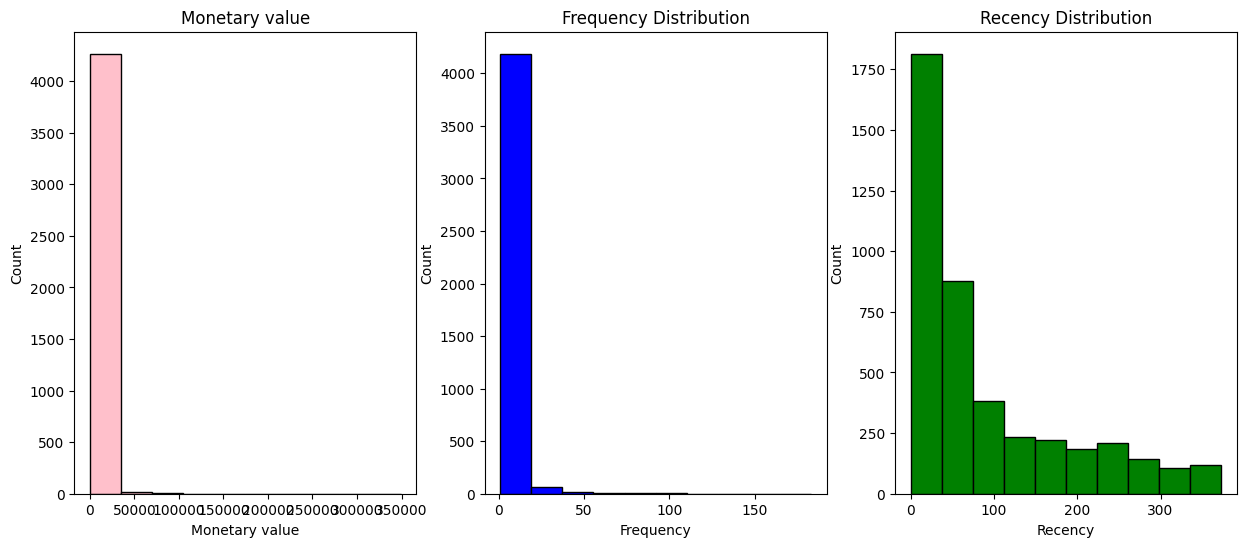

In [ ]:
plt.figure(figsize = (15,6))

plt.subplot(1,3,1)
plt.hist(aggregate_df['MonetaryValue'], bins=10,color = 'pink',edgecolor = 'black')
plt.title('Monetary value')
plt.xlabel('Monetary value')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(aggregate_df['Frequency'], bins = 10, color = 'blue', edgecolor = 'black')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
plt.hist(aggregate_df['Recency'], bins = 10, color = 'green', edgecolor = 'black')
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title('Recency Distribution')


Text(0, 0.5, 'Count')

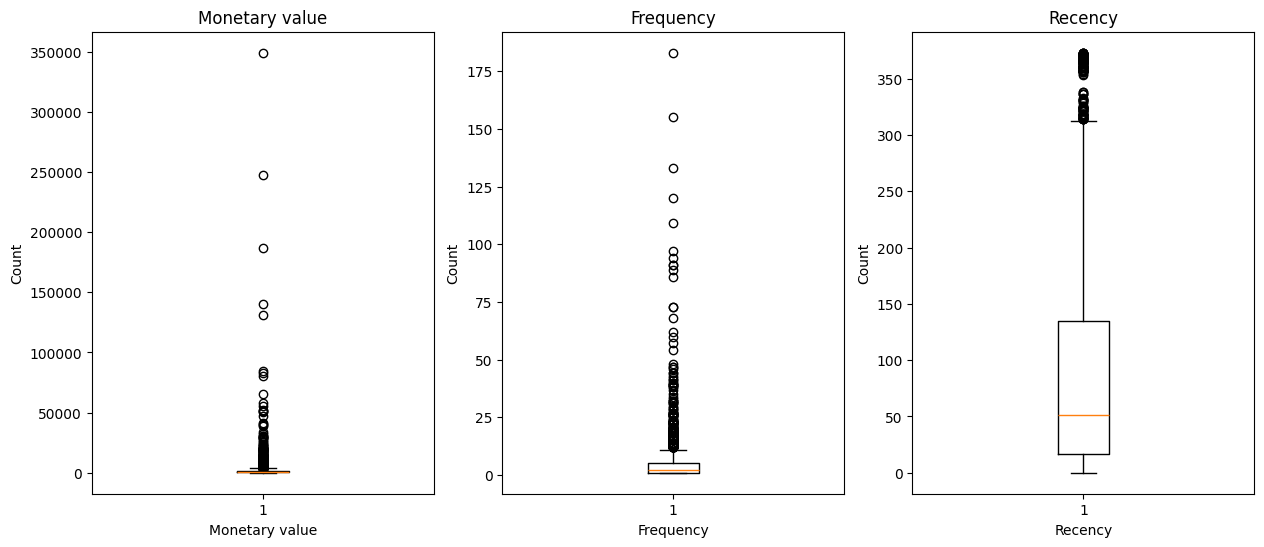

In [ ]:
# Checking for the ouliers
plt.figure(figsize = (15,6))

plt.subplot(1,3,1)
plt.boxplot(aggregate_df['MonetaryValue'])
plt.title('Monetary value')
plt.xlabel('Monetary value')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.boxplot(aggregate_df['Frequency'])
plt.title('Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.boxplot(aggregate_df['Recency'])
plt.title('Recency')
plt.xlabel('Recency')
plt.ylabel('Count')

In [ ]:
Q1 = aggregate_df['MonetaryValue'].quantile(0.25)
Q3 = aggregate_df['MonetaryValue'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
monetary_outliers_df = aggregate_df[(aggregate_df['MonetaryValue']<(Q1-1.5*IQR)) | (aggregate_df['MonetaryValue']>(Q3+1.5*IQR))]
monetary_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
9,12357.0,11229.99,1,2010-11-16 10:05:00,23
25,12380.0,4782.84,4,2010-08-31 14:54:00,100
42,12409.0,12346.62,4,2010-10-15 10:24:00,55
48,12415.0,19468.84,4,2010-11-29 15:07:00,10
61,12431.0,4145.52,11,2010-12-01 10:03:00,8
...,...,...,...,...,...
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41
4253,18251.0,21964.14,8,2010-09-20 13:26:00,80


In [ ]:
# removing the outliers for frequencey column
Q1 = aggregate_df['Frequency'].quantile(0.25)
Q3 = aggregate_df['Frequency'].quantile(0.75)
IQR = Q3 - Q1

Frequency_ouliers = aggregate_df[(aggregate_df['Frequency']<(Q1-1.5*IQR)) | (aggregate_df['Frequency']>(Q3+1.5*IQR))]
Frequency_ouliers

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
65,12437.0,6834.99,20,2010-11-09 14:46:00,30
84,12471.0,17721.45,44,2010-11-30 14:35:00,9
85,12472.0,10426.48,13,2010-12-05 14:19:00,4
92,12482.0,21941.72,27,2010-05-12 16:51:00,211
115,12523.0,2330.38,12,2010-11-30 12:31:00,9
...,...,...,...,...,...
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41
4250,18245.0,3757.92,13,2010-11-25 16:52:00,14


In [ ]:
# Deleting the outliers that are common in both the frequency and the monetary value.
Non_outliers_df = aggregate_df[(~aggregate_df.index.isin(monetary_outliers_df.index)) & (~aggregate_df.index.isin(Frequency_ouliers.index))]
Non_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17
4281,18284.0,411.68,1,2010-10-04 11:33:00,66
4282,18285.0,377.00,1,2010-02-17 10:24:00,295
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111


Text(0, 0.5, 'Count')

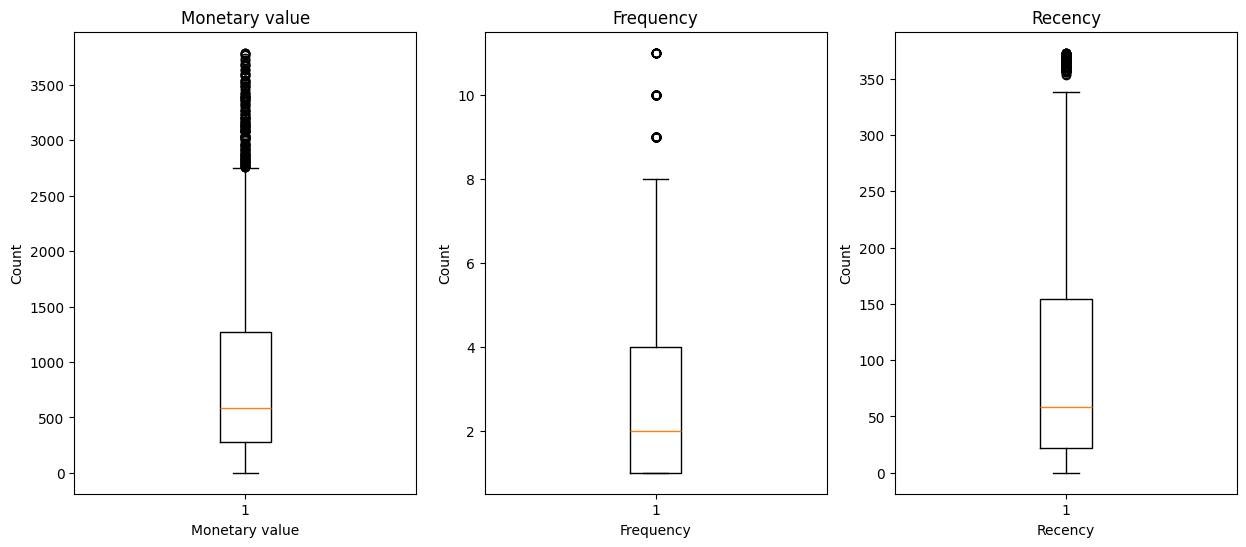

In [ ]:
# Plotting the box plots to check for the remaining ouliers.

plt.figure(figsize = (15,6))

plt.subplot(1,3,1)
plt.boxplot(Non_outliers_df['MonetaryValue'])
plt.title('Monetary value')
plt.xlabel('Monetary value')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.boxplot(Non_outliers_df['Frequency'])
plt.title('Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.boxplot(Non_outliers_df['Recency'])
plt.title('Recency')
plt.xlabel('Recency')
plt.ylabel('Count')

Text(0.5, 0, 'Recency')

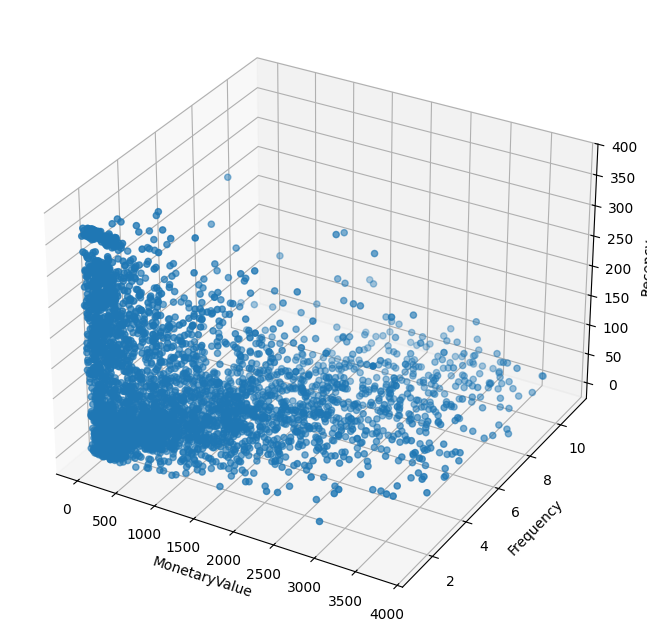

In [ ]:
# Plotting a 3D scatter plot for the customers
plt.figure(figsize = (18,8))
ax = plt.axes(projection = '3d')
ax.scatter(Non_outliers_df['MonetaryValue'],Non_outliers_df['Frequency'],Non_outliers_df['Recency'])
ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

In [ ]:
# Now scaling the features using the standard scaler from sklearn
scaler = StandardScaler()
scaled_df = scaler.fit_transform(Non_outliers_df[['MonetaryValue','Frequency','Recency']])
scaled_df

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.5355144 , -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488781,  0.50659348, -0.81634357]])

In [ ]:
scaled_df = pd.DataFrame(scaled_df,index = Non_outliers_df.index, columns = ['MonetaryValue','Frequency','Recency'])
scaled_df

,MonetaryValue,Frequency,Recency
0,-0.875945,-0.384889,0.682149
1,0.535514,-0.384889,-0.969251
2,-0.812586,-0.830631,-0.245489
3,1.633678,-0.384889,-0.561498
4,-0.715016,-0.830631,-0.887700
...,...,...,...
4280,-0.298120,1.398076,-0.816344
4281,-0.579553,-0.830631,-0.316846
4282,-0.621972,-0.830631,2.017539
4283,0.441467,-0.384889,0.141876


Text(0.5, 0, 'Recency')

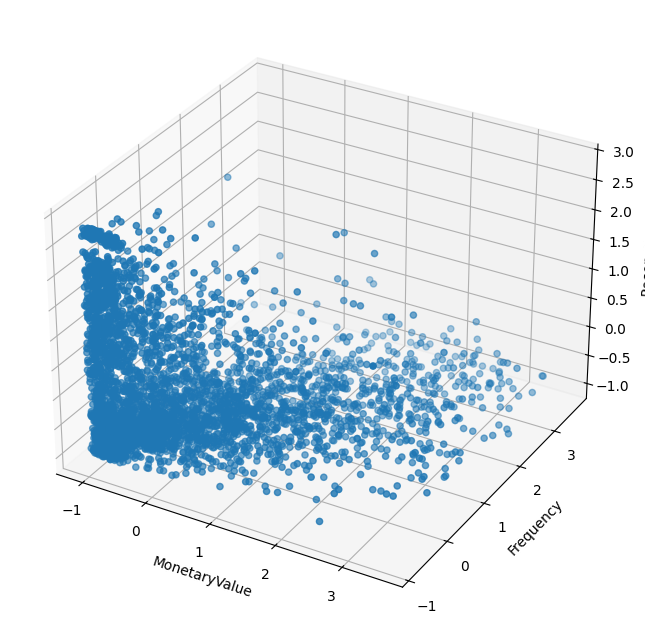

In [ ]:
plt.figure(figsize = (8,8))
ax = plt.axes(projection = '3d')
ax.scatter(scaled_df['MonetaryValue'],scaled_df['Frequency'],scaled_df['Recency'])
ax.set_xlabel('MonetaryValue')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

## K Means Clustring

Text(0, 0.5, 'Shilloutte Score')

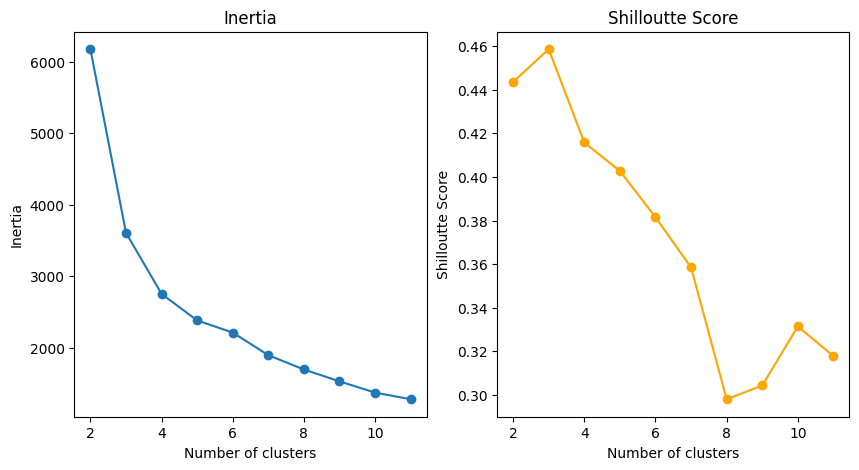

In [ ]:
clusters = 12
shilloutte_scores = []
inertia = []


for k in range(2,clusters):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(scaled_df)
    shilloutte_scores.append(silhouette_score(scaled_df,kmeans.labels_))
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(range(2,clusters,),inertia,marker = 'o')
plt.title('Inertia')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(range(2,clusters,),shilloutte_scores,marker = 'o',color='orange')
plt.title('Shilloutte Score')
plt.xlabel('Number of clusters')
plt.ylabel('Shilloutte Score')





The silhoutte score ranges between [-1,1] a higher value indicates more distinct clusters.

In [ ]:
kmeans = KMeans(n_clusters= 4, max_iter = 1000, random_state = 42)
clustre_labels = kmeans.fit_predict(scaled_df)
clustre_labels

array([1, 0, 2, ..., 1, 0, 0], dtype=int32)

In [ ]:
Non_outliers_df['Cluster'] = clustre_labels
Non_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.0,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.0,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111,0


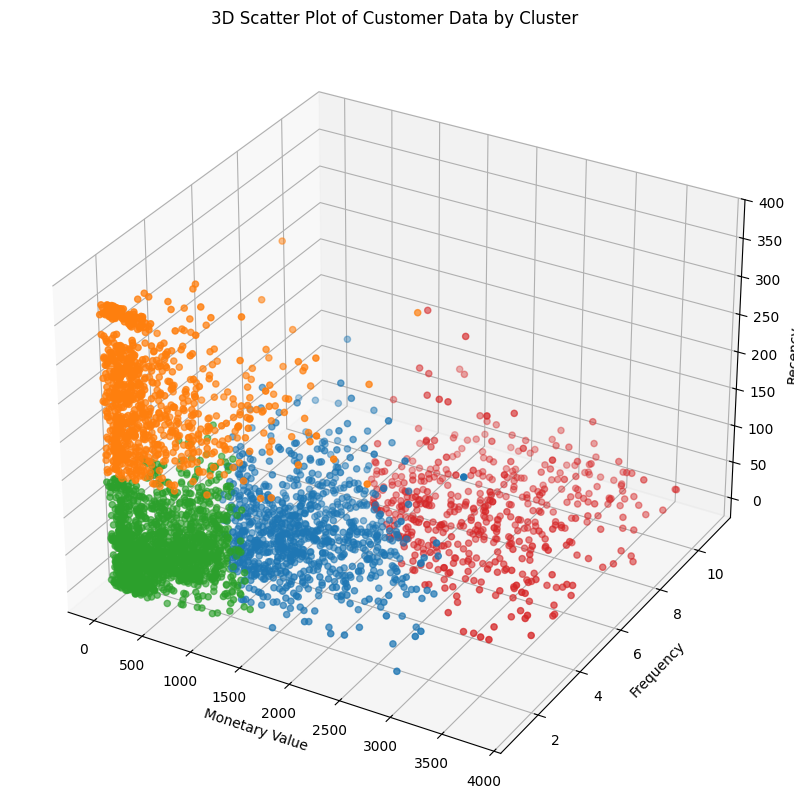

In [ ]:
cluster_colors = {0: '#1f77b4',  # Blue
                  1: '#ff7f0e',  # Orange
                  2: '#2ca02c',  # Green
                  3: '#d62728'}  # Red

colors = Non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(Non_outliers_df['MonetaryValue'],
                     Non_outliers_df['Frequency'],
                     Non_outliers_df['Recency'],
                     c=colors,  # Use mapped solid colors
                     marker='o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data by Cluster')

plt.show()

Text(0, 0.5, 'Recency')

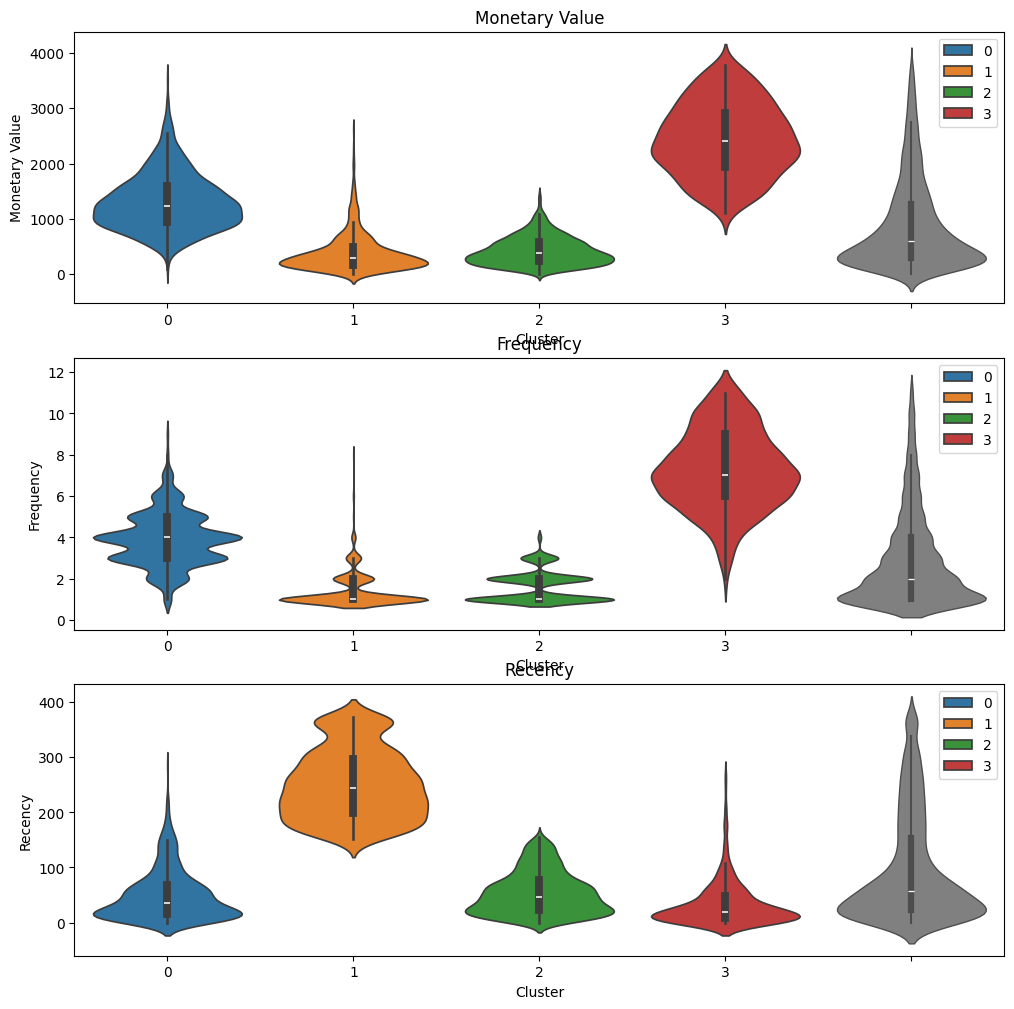

In [ ]:
# Understanding the clustres
plt.figure(figsize=(12,12))

plt.subplot(3,1,1)
sns.violinplot(x='Cluster',y='MonetaryValue',data=Non_outliers_df,palette=cluster_colors,hue = 'Cluster')
sns.violinplot(y=Non_outliers_df['MonetaryValue'],color = 'gray',linewidth=1.0)
plt.title('Monetary Value')
plt.xlabel('Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x='Cluster',y='Frequency',data=Non_outliers_df,palette=cluster_colors,hue = 'Cluster')
sns.violinplot(y=Non_outliers_df['Frequency'],color = 'gray',linewidth=1.0)
plt.title('Frequency')
plt.xlabel('Cluster')


plt.subplot(3,1,3)
sns.violinplot(x='Cluster',y='Recency',data=Non_outliers_df,palette=cluster_colors,hue = 'Cluster')
sns.violinplot(y=Non_outliers_df['Recency'],color = 'gray',linewidth=1.0)
plt.title('Recency')
plt.xlabel('Cluster')
plt.ylabel('Recency')

Cluster 0 (Blue): "Retain"

Rationale: This cluster represents high-value customers who purchase regularly, though not always very recently. The focus should be on retention efforts to maintain their loyalty and spending levels.
Action: Implement loyalty programs, personalized offers, and regular engagement to ensure they remain active.


Cluster 1 (Orange): "Re-Engage"

Rationale: This group includes lower-value, infrequent buyers who haven’t purchased recently. The focus should be on re-engagement to bring them back into active purchasing behavior.
Action: Use targeted marketing campaigns, special discounts, or reminders to encourage them to return and purchase again.


Cluster 2 (Green): "Nurture"

Rationale: This cluster represents the least active and lowest-value customers, but they have made recent purchases. These customers may be new or need nurturing to increase their engagement and spending.
Action: Focus on building relationships, providing excellent customer service, and offering incentives to encourage more frequent purchases.


Cluster 3 (Red): "Reward"

Rationale: This cluster includes high-value, very frequent buyers, many of whom are still actively purchasing. They are your most loyal customers, and rewarding their loyalty is key to maintaining their engagement.


Action: Implement a robust loyalty program, provide exclusive offers, and recognize their loyalty to keep them engaged and satisfied.
Summary of Cluster Names:


Cluster 0 (Blue): "Retain"

Cluster 1 (Orange): "Re-Engage"

Cluster 2 (Green): "Nurture"

Cluster 3 (Red): "Reward"